# Phase 2 Results — Reliability-Aware Surface Inference

**Date:** 2026-05-25 · **Benchmark:** `spy_phase1_random40_noiselow` on
Alpha Vantage SPY (22.5M strict-cleaned rows, chronological 11.1M / 5.6M
/ 5.8M train / val / test).

## TL;DR

Phase 2 closes the reliability layer on top of Phase 1's surface
interpolation floor. The system now emits **six decision-grade outputs
per query** (`sigma_hat`, `confidence_score`, `(lower, upper)` band,
`abstain_flag`, `tradability_score`, `no_arb_risk_flags`), and both
mandatory acceptance numbers pass on real AV data:

| Acceptance bar (§5 / §6)                         | Result                                                                                                                     | Status |
|---|---|---|
| Empirical coverage at α = 0.90 within ±2 pp      | **0.9184** on 2D.9 test slice (\|Δ\| = 1.84 pp); **0.8955** on full 2D.4 test fold (\|Δ\| = 0.45 pp)                    | PASS   |
| Hi-conf MAE < no-abstention test MAE             | **0.0606** at `keep_fraction=0.8` vs **0.0855** no-abstention test MAE (≈ 29 % reduction)                                  | PASS   |

Companion executive memo: [`../docs/phase2_result_memo.md`](../docs/phase2_result_memo.md).


## 1. Setup

This notebook reads only committed artifacts — no model load, no training,
no scoring.

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

REPO = Path('..').resolve()
RESULTS = REPO / 'results' / '2D'
DATASET = 'spy_phase1_random40_noiselow'
PRED_DIR = RESULTS / DATASET
RUNS = REPO / 'artifacts' / 'runs'

PREDICTORS = ['interpolation', 'masked_mlp', 'conditional_point', 'conditional_calibrated']

colors = {
    'interpolation':           '#7f7f7f',
    'masked_mlp':              '#2ca02c',
    'conditional_point':       '#1f77b4',
    'conditional_calibrated':  '#d62728',
}

pd.set_option('display.float_format', '{:.4f}'.format)
print('REPO =', REPO)
print('RESULTS dir exists:', RESULTS.exists())


REPO = /Users/mengziyue/Neural IV Surface inference
RESULTS dir exists: True


## 2. Headline results

Source: [`results/2D/comparison_summary.csv`](../results/2D/comparison_summary.csv)
— produced by `scripts/run_decision_layer_eval.py` (2D.9, 10-date cap per
split = 64,610 test rows).

Coverage / mean-width are reported only for the calibrated predictor.
Baseline predictors flow through the W5 decision layer via a degenerate
full-confidence shim so the runner can score them uniformly.

In [2]:
summary = pd.read_csv(RESULTS / 'comparison_summary.csv')
summary = summary.set_index('predictor').loc[PREDICTORS].reset_index()
summary[['predictor','test_mae','hi_conf_mae','coverage_90','mean_width',
         'abstain_rate','mean_tradability','n_forbidden_flag_violations']]


,predictor,test_mae,hi_conf_mae,coverage_90,mean_width,abstain_rate,mean_tradability,n_forbidden_flag_violations
0,interpolation,0.0730,0.0742,0.0000,0.0000,0.5690,0.9431,43406
1,masked_mlp,0.0905,0.0919,0.0000,0.0000,0.0155,0.9985,1004
2,conditional_point,0.0841,0.0856,0.0000,0.0000,0.0987,0.9901,7381
3,conditional_calibrated,0.0855,0.0606,0.9184,0.3658,1.0000,0.2789,7476


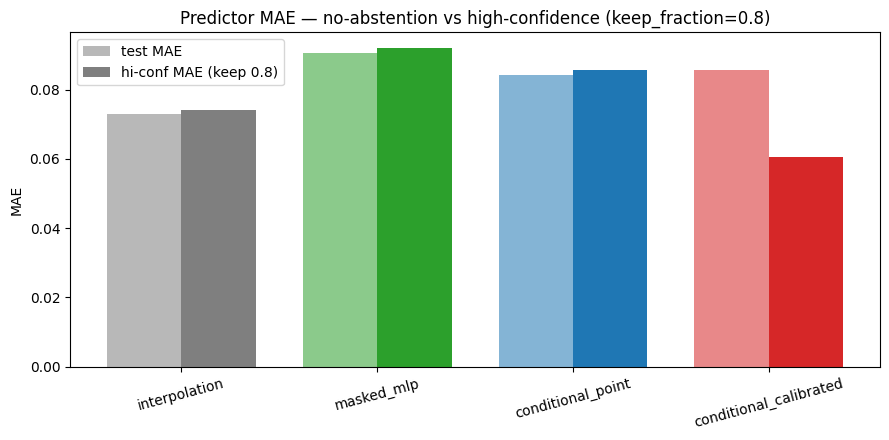

In [3]:
# Bar chart: test MAE vs hi-conf MAE per predictor
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(summary))
w = 0.38
ax.bar(x - w/2, summary['test_mae'],    w, label='test MAE',
       color=[colors[p] for p in summary['predictor']], alpha=0.55)
ax.bar(x + w/2, summary['hi_conf_mae'], w, label='hi-conf MAE (keep 0.8)',
       color=[colors[p] for p in summary['predictor']])
ax.set_xticks(x)
ax.set_xticklabels(summary['predictor'], rotation=15)
ax.set_ylabel('MAE')
ax.set_title('Predictor MAE — no-abstention vs high-confidence (keep_fraction=0.8)')
ax.legend()
plt.tight_layout(); plt.show()


## 3. Per-predictor evidence pages

For each of the four predictors we display the committed calibration plot,
abstention curve, per-region tradability table, and split-level metrics.

All figures and tables are referenced by path — nothing is recomputed.

### 3.1. `interpolation`

metrics_summary.csv:


,split,n,mae,coverage_90,mean_width,hi_conf_mae_keep0.8,abstain_rate,mean_tradability,n_forbidden_flag_violations
0,train,13587,0.0377,0.0000,0.0000,0.0378,0.3444,0.9656,4986
1,val,86671,0.0358,0.0000,0.0000,0.0374,0.3878,0.9612,36953
2,test,64610,0.0730,0.0000,0.0000,0.0742,0.5690,0.9431,43406


region_tradability.csv (top 10 rows):


,dataset,predictor,split,maturity,moneyness,mean_tradability,abstain_rate,n_points
0,spy_phase1_random40_noiselow,interpolation,train,short,deep_itm,0.9833,0.1674,460.0000
1,spy_phase1_random40_noiselow,interpolation,train,short,itm,0.9739,0.2606,284.0000
2,spy_phase1_random40_noiselow,interpolation,train,short,atm,0.9680,0.3204,284.0000
3,spy_phase1_random40_noiselow,interpolation,train,short,otm,0.9807,0.1929,311.0000
4,spy_phase1_random40_noiselow,interpolation,train,short,deep_otm,0.9746,0.2538,130.0000
5,spy_phase1_random40_noiselow,interpolation,train,medium,deep_itm,0.9714,0.2856,2311.0000
6,spy_phase1_random40_noiselow,interpolation,train,medium,itm,0.9824,0.1760,1148.0000
7,spy_phase1_random40_noiselow,interpolation,train,medium,atm,0.9553,0.4471,1342.0000
8,spy_phase1_random40_noiselow,interpolation,train,medium,otm,0.9516,0.4841,1735.0000
9,spy_phase1_random40_noiselow,interpolation,train,medium,deep_otm,0.9619,0.3814,485.0000


calibration_plot.png:


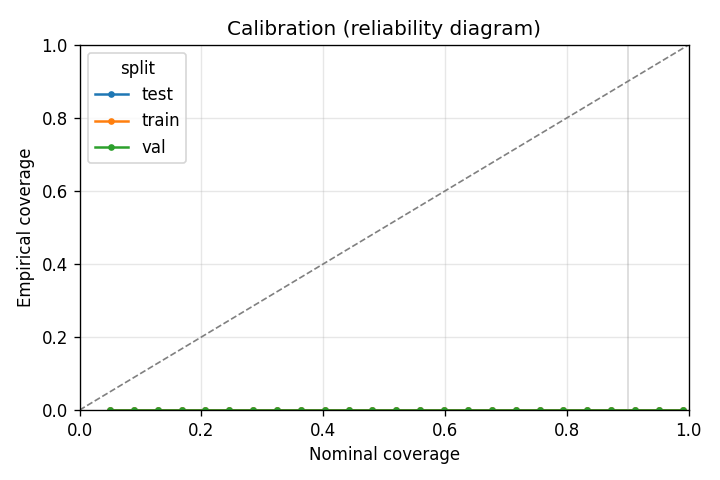

abstention_curve.png:


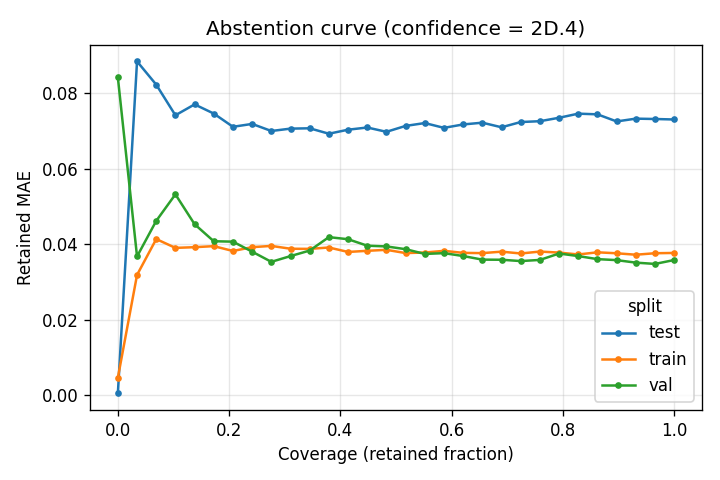

In [4]:
p = 'interpolation'
pdir = PRED_DIR / p
print('metrics_summary.csv:')
display(pd.read_csv(pdir / 'metrics_summary.csv'))
print('region_tradability.csv (top 10 rows):')
display(pd.read_csv(pdir / 'region_tradability.csv').head(10))
print('calibration_plot.png:')
display(Image(filename=str(pdir / 'calibration_plot.png')))
print('abstention_curve.png:')
display(Image(filename=str(pdir / 'abstention_curve.png')))


### 3.2. `masked_mlp`

metrics_summary.csv:


,split,n,mae,coverage_90,mean_width,hi_conf_mae_keep0.8,abstain_rate,mean_tradability,n_forbidden_flag_violations
0,train,13587,0.1678,0.0000,0.0000,0.1682,0.0209,0.9979,286
1,val,86671,0.0957,0.0000,0.0000,0.0920,0.0029,0.9997,256
2,test,64610,0.0905,0.0000,0.0000,0.0919,0.0155,0.9985,1004


region_tradability.csv (top 10 rows):


,dataset,predictor,split,maturity,moneyness,mean_tradability,abstain_rate,n_points
0,spy_phase1_random40_noiselow,masked_mlp,train,short,deep_itm,1.0000,0.0000,460.0000
1,spy_phase1_random40_noiselow,masked_mlp,train,short,itm,1.0000,0.0000,284.0000
2,spy_phase1_random40_noiselow,masked_mlp,train,short,atm,1.0000,0.0000,284.0000
3,spy_phase1_random40_noiselow,masked_mlp,train,short,otm,1.0000,0.0000,311.0000
4,spy_phase1_random40_noiselow,masked_mlp,train,short,deep_otm,0.9869,0.1308,130.0000
5,spy_phase1_random40_noiselow,masked_mlp,train,medium,deep_itm,1.0000,0.0000,2311.0000
6,spy_phase1_random40_noiselow,masked_mlp,train,medium,itm,0.9998,0.0017,1148.0000
7,spy_phase1_random40_noiselow,masked_mlp,train,medium,atm,0.9999,0.0007,1342.0000
8,spy_phase1_random40_noiselow,masked_mlp,train,medium,otm,0.9938,0.0617,1735.0000
9,spy_phase1_random40_noiselow,masked_mlp,train,medium,deep_otm,0.9682,0.3175,485.0000


calibration_plot.png:


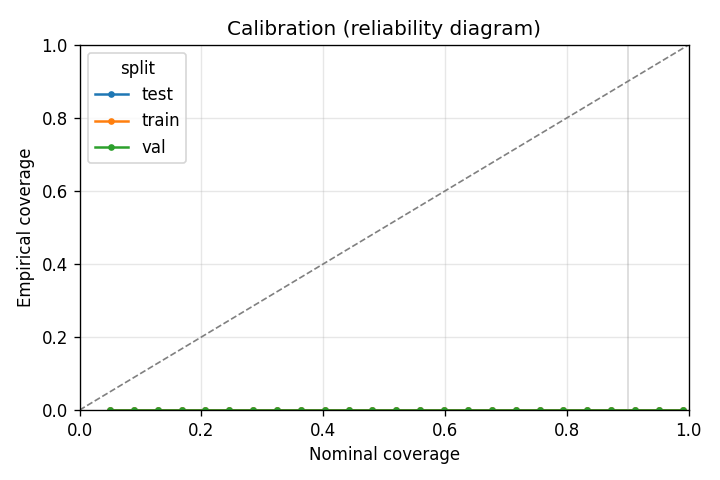

abstention_curve.png:


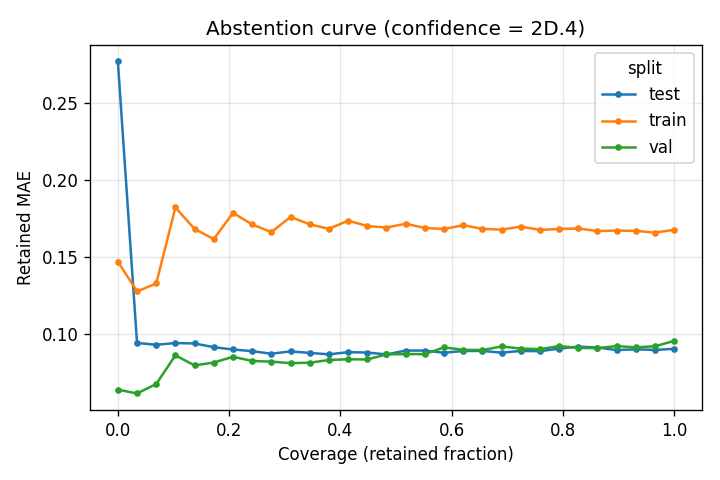

In [5]:
p = 'masked_mlp'
pdir = PRED_DIR / p
print('metrics_summary.csv:')
display(pd.read_csv(pdir / 'metrics_summary.csv'))
print('region_tradability.csv (top 10 rows):')
display(pd.read_csv(pdir / 'region_tradability.csv').head(10))
print('calibration_plot.png:')
display(Image(filename=str(pdir / 'calibration_plot.png')))
print('abstention_curve.png:')
display(Image(filename=str(pdir / 'abstention_curve.png')))


### 3.3. `conditional_point`

metrics_summary.csv:


,split,n,mae,coverage_90,mean_width,hi_conf_mae_keep0.8,abstain_rate,mean_tradability,n_forbidden_flag_violations
0,train,13587,0.0752,0.0000,0.0000,0.0756,0.1382,0.9862,1886
1,val,86671,0.0388,0.0000,0.0000,0.0403,0.0256,0.9974,2590
2,test,64610,0.0841,0.0000,0.0000,0.0856,0.0987,0.9901,7381


region_tradability.csv (top 10 rows):


,dataset,predictor,split,maturity,moneyness,mean_tradability,abstain_rate,n_points
0,spy_phase1_random40_noiselow,conditional_point,train,short,deep_itm,1.0000,0.0000,460.0000
1,spy_phase1_random40_noiselow,conditional_point,train,short,itm,1.0000,0.0000,284.0000
2,spy_phase1_random40_noiselow,conditional_point,train,short,atm,0.9954,0.0458,284.0000
3,spy_phase1_random40_noiselow,conditional_point,train,short,otm,0.9887,0.1125,311.0000
4,spy_phase1_random40_noiselow,conditional_point,train,short,deep_otm,1.0000,0.0000,130.0000
5,spy_phase1_random40_noiselow,conditional_point,train,medium,deep_itm,0.9893,0.1069,2311.0000
6,spy_phase1_random40_noiselow,conditional_point,train,medium,itm,0.9495,0.5052,1148.0000
7,spy_phase1_random40_noiselow,conditional_point,train,medium,atm,0.9869,0.1311,1342.0000
8,spy_phase1_random40_noiselow,conditional_point,train,medium,otm,0.9976,0.0242,1735.0000
9,spy_phase1_random40_noiselow,conditional_point,train,medium,deep_otm,1.0000,0.0000,485.0000


calibration_plot.png:


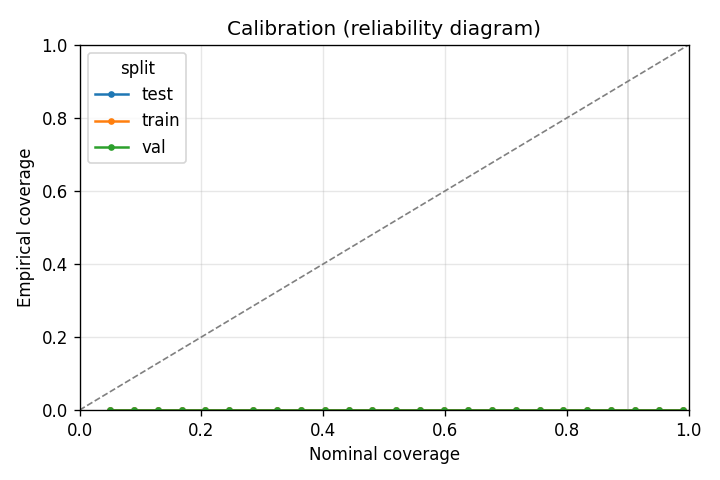

abstention_curve.png:


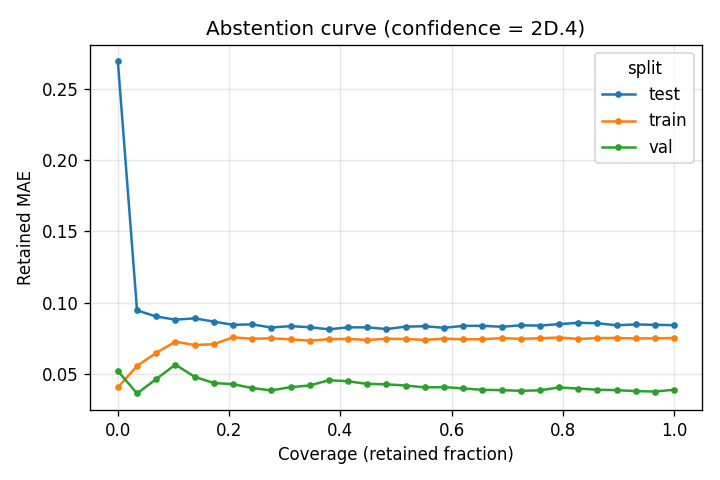

In [6]:
p = 'conditional_point'
pdir = PRED_DIR / p
print('metrics_summary.csv:')
display(pd.read_csv(pdir / 'metrics_summary.csv'))
print('region_tradability.csv (top 10 rows):')
display(pd.read_csv(pdir / 'region_tradability.csv').head(10))
print('calibration_plot.png:')
display(Image(filename=str(pdir / 'calibration_plot.png')))
print('abstention_curve.png:')
display(Image(filename=str(pdir / 'abstention_curve.png')))


### 3.4. `conditional_calibrated`

metrics_summary.csv:


,split,n,mae,coverage_90,mean_width,hi_conf_mae_keep0.8,abstain_rate,mean_tradability,n_forbidden_flag_violations
0,train,13587,0.0795,0.9538,0.3359,0.0619,1.0000,0.2580,1884
1,val,86671,0.0448,0.9650,0.2111,0.0203,1.0000,0.3862,2963
2,test,64610,0.0855,0.9184,0.3658,0.0606,1.0000,0.2789,7476


region_tradability.csv (top 10 rows):


,dataset,predictor,split,maturity,moneyness,mean_tradability,abstain_rate,n_points
0,spy_phase1_random40_noiselow,conditional_calibrated,train,short,deep_itm,0.1035,1.0000,460.0000
1,spy_phase1_random40_noiselow,conditional_calibrated,train,short,itm,0.1120,1.0000,284.0000
2,spy_phase1_random40_noiselow,conditional_calibrated,train,short,atm,0.1491,1.0000,284.0000
3,spy_phase1_random40_noiselow,conditional_calibrated,train,short,otm,0.1881,1.0000,311.0000
4,spy_phase1_random40_noiselow,conditional_calibrated,train,short,deep_otm,0.1967,1.0000,130.0000
5,spy_phase1_random40_noiselow,conditional_calibrated,train,medium,deep_itm,0.1331,1.0000,2311.0000
6,spy_phase1_random40_noiselow,conditional_calibrated,train,medium,itm,0.1738,1.0000,1148.0000
7,spy_phase1_random40_noiselow,conditional_calibrated,train,medium,atm,0.2705,1.0000,1342.0000
8,spy_phase1_random40_noiselow,conditional_calibrated,train,medium,otm,0.3890,1.0000,1735.0000
9,spy_phase1_random40_noiselow,conditional_calibrated,train,medium,deep_otm,0.4145,1.0000,485.0000


calibration_plot.png:


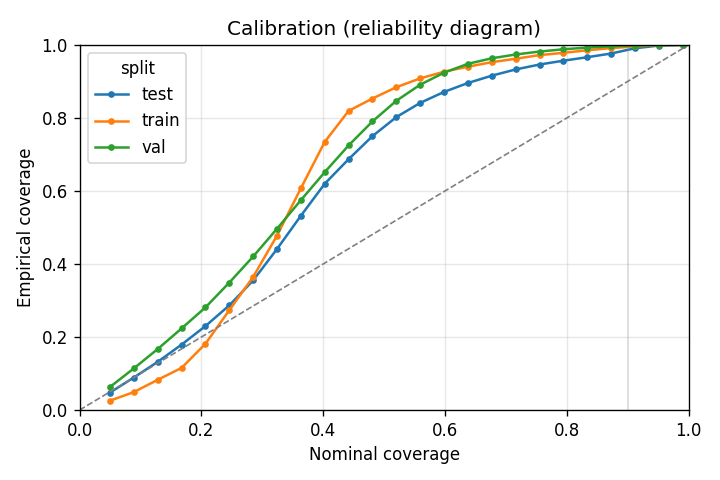

abstention_curve.png:


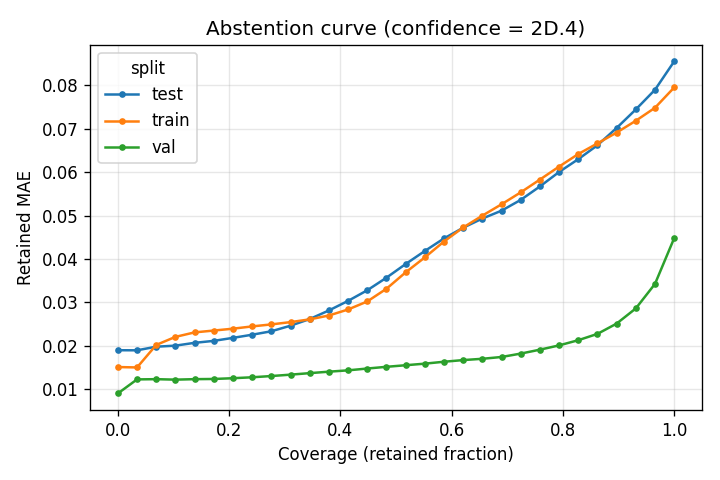

In [7]:
p = 'conditional_calibrated'
pdir = PRED_DIR / p
print('metrics_summary.csv:')
display(pd.read_csv(pdir / 'metrics_summary.csv'))
print('region_tradability.csv (top 10 rows):')
display(pd.read_csv(pdir / 'region_tradability.csv').head(10))
print('calibration_plot.png:')
display(Image(filename=str(pdir / 'calibration_plot.png')))
print('abstention_curve.png:')
display(Image(filename=str(pdir / 'abstention_curve.png')))


## 4. Worked single-date example — calibrated conditional predictor

We pick the test date with the densest `(k, τ)` coverage and render all
six decision-grade outputs as heatmaps over a `(log_moneyness, tau)` grid.

Source: `predictions_decisions.csv` is gitignored (45 MB per pair) but is
re-derivable by re-running `scripts/run_decision_layer_eval.py`. If the
file is missing locally, this section emits an explanatory cell instead
of failing.

In [8]:
preds_path = PRED_DIR / 'conditional_calibrated' / 'predictions_decisions.csv'
HAVE_PREDS = preds_path.exists()
if HAVE_PREDS:
    preds = pd.read_csv(preds_path)
    test = preds[preds['split'] == 'test']
    by_date = test.groupby('date').size().sort_values(ascending=False)
    EXAMPLE_DATE = by_date.index[0]
    slice_ = test[test['date'] == EXAMPLE_DATE].copy()
    print(f'EXAMPLE_DATE = {EXAMPLE_DATE}   rows = {len(slice_)}')
    display(slice_.head(5))
else:
    print(f'NOTE: {preds_path.relative_to(REPO)} is gitignored and not present locally.')
    print('Worked-example heatmaps skipped. Regenerate with scripts/run_decision_layer_eval.py.')
    slice_ = None
    EXAMPLE_DATE = None


EXAMPLE_DATE = 2023-08-18   rows = 6698


,dataset,predictor,split,date,log_moneyness,tau,iv_true,iv_pred,uncertainty,lower,upper,confidence_score,abstain_flag,tradability_score,decision_reason,calendar_violation,monotonicity_violation,convexity_violation
106656,spy_phase1_random40_noiselow,conditional_calibrated,test,2023-08-18,-0.2067,0.0082,0.0149,0.4834,0.8532,-0.7701,1.7368,0.0000,True,0.1000,low_confidence,False,False,False
106657,spy_phase1_random40_noiselow,conditional_calibrated,test,2023-08-18,-0.1927,0.0082,0.0149,0.4816,0.8091,-0.7177,1.6810,0.0000,True,0.1000,low_confidence,False,False,False
106658,spy_phase1_random40_noiselow,conditional_calibrated,test,2023-08-18,-0.1789,0.0082,0.0149,0.4788,0.7592,-0.6536,1.6113,0.0000,True,0.1000,low_confidence,False,False,False
106659,spy_phase1_random40_noiselow,conditional_calibrated,test,2023-08-18,-0.1653,0.0082,0.0149,0.4742,0.7015,-0.5759,1.5243,0.0000,True,0.1000,low_confidence,False,False,False
106660,spy_phase1_random40_noiselow,conditional_calibrated,test,2023-08-18,-0.1545,0.0082,0.0149,0.4686,0.6488,-0.5033,1.4404,0.0000,True,0.1000,low_confidence,False,False,False


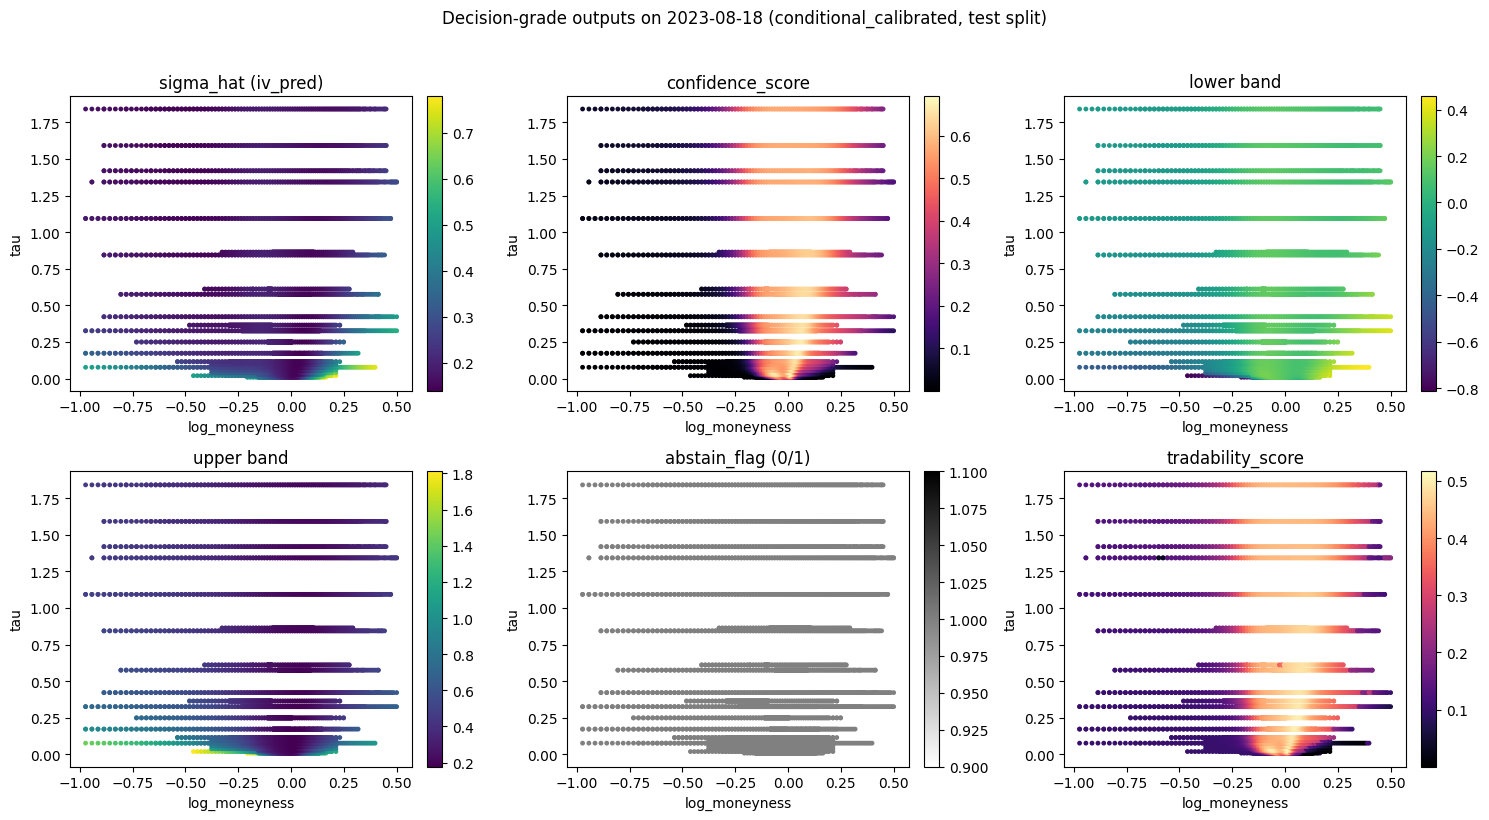

In [9]:
def _scatter_heatmap(ax, x, y, c, title, cmap='viridis', vmin=None, vmax=None):
    sc = ax.scatter(x, y, c=c, s=6, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xlabel('log_moneyness'); ax.set_ylabel('tau')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

if HAVE_PREDS and slice_ is not None and len(slice_) > 0:
    panels = [
        ('iv_pred',           'sigma_hat (iv_pred)',     'viridis'),
        ('confidence_score',  'confidence_score',        'magma'),
        ('lower',             'lower band',              'viridis'),
        ('upper',             'upper band',              'viridis'),
        ('abstain_flag',      'abstain_flag (0/1)',      'gray_r'),
        ('tradability_score', 'tradability_score',       'magma'),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, (col, title, cmap) in zip(axes.flat, panels):
        _scatter_heatmap(ax, slice_['log_moneyness'], slice_['tau'],
                         slice_[col], title, cmap=cmap)
    plt.suptitle(f'Decision-grade outputs on {EXAMPLE_DATE} '
                 f'(conditional_calibrated, test split)',
                 y=1.02)
    plt.tight_layout(); plt.show()
else:
    print('skipped — predictions_decisions.csv not available locally')


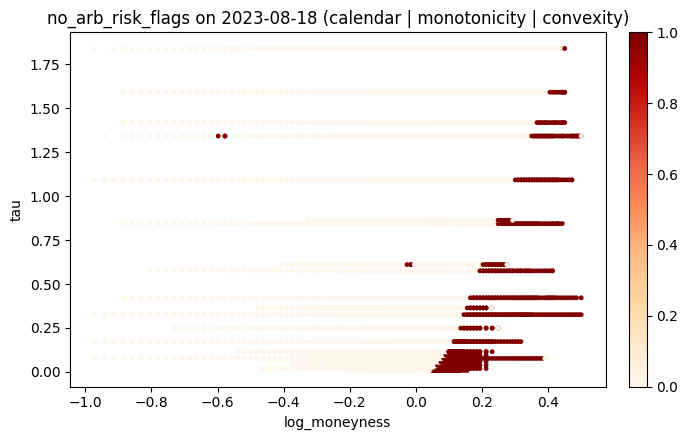

decision_reason distribution on this date:


decision_reason
low_confidence      3450
wide_interval       2770
no_arb_violation     478
Name: count, dtype: int64

In [10]:
if HAVE_PREDS and slice_ is not None and len(slice_) > 0:
    # no_arb_risk_flags: combined violation indicator (OR of the three)
    slice_['no_arb_risk_flags'] = (
        slice_['calendar_violation'].fillna(0).astype(int)
        | slice_['monotonicity_violation'].fillna(0).astype(int)
        | slice_['convexity_violation'].fillna(0).astype(int)
    )
    fig, ax = plt.subplots(figsize=(7, 4.5))
    _scatter_heatmap(ax, slice_['log_moneyness'], slice_['tau'],
                     slice_['no_arb_risk_flags'],
                     f'no_arb_risk_flags on {EXAMPLE_DATE} '
                     f'(calendar | monotonicity | convexity)',
                     cmap='OrRd', vmin=0, vmax=1)
    plt.tight_layout(); plt.show()

    print('decision_reason distribution on this date:')
    display(slice_['decision_reason'].value_counts(dropna=False))
else:
    print('skipped — predictions_decisions.csv not available locally')


## 5. Training dynamics

### 5.1 Per-head training curves (2D.7)

Source: `artifacts/runs/2D7/<head_kind>/training_curve.csv`. Three heads
were trained on full AV data: `gaussian` (NLL), `quantile` (pinball), and
`point` (MSE control).


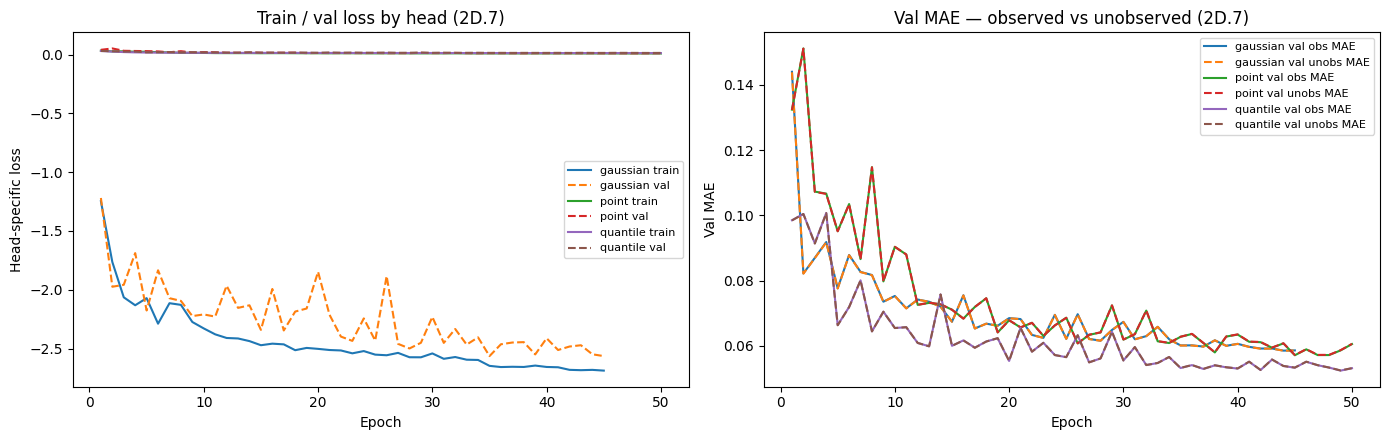

In [11]:
heads = ['gaussian', 'point', 'quantile']
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for h in heads:
    curve = pd.read_csv(RUNS / '2D7' / h / 'training_curve.csv')
    axes[0].plot(curve['epoch'], curve['train_loss'], label=f'{h} train')
    axes[0].plot(curve['epoch'], curve['val_loss'],   linestyle='--', label=f'{h} val')
    axes[1].plot(curve['epoch'], curve['val_obs_mae'],   label=f'{h} val obs MAE')
    axes[1].plot(curve['epoch'], curve['val_unobs_mae'], linestyle='--', label=f'{h} val unobs MAE')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Head-specific loss')
axes[0].set_title('Train / val loss by head (2D.7)'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val MAE')
axes[1].set_title('Val MAE — observed vs unobserved (2D.7)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


In [12]:
# Per-head final stats from the manifests
rows = []
for h in heads:
    m = json.loads((RUNS / '2D7' / h / 'manifest.json').read_text())
    rows.append({
        'head': h,
        'epochs_completed': m.get('epochs_completed'),
        'final_val_loss':   m.get('final_val_loss'),
        'best_val_loss':    m.get('best_val_loss'),
        'val_mae_mu':       m.get('val_mae_mu'),
        'test_mae_mu':      m.get('test_mae_mu'),
        'train_wall_clock_s': round(m.get('train_wall_clock_s', float('nan')), 1),
    })
pd.DataFrame(rows)


,head,epochs_completed,final_val_loss,best_val_loss,val_mae_mu,test_mae_mu,train_wall_clock_s
0,gaussian,45,-2.5635,-2.5635,0.0606,0.0787,92.9000
1,point,50,0.0106,0.0100,0.0577,0.0756,102.2000
2,quantile,50,0.0136,0.0133,0.0530,0.0719,103.5000


### 5.2 Ensemble training curves (2D.8)

Source: `artifacts/runs/2D8/training_curves.csv` — five seeds (101, 202,
303, 404, 505) trained with the point head + MSE loss. The ensemble-mean
test MAE is **0.0747**, ensemble-disagreement std mean is **0.0094**.


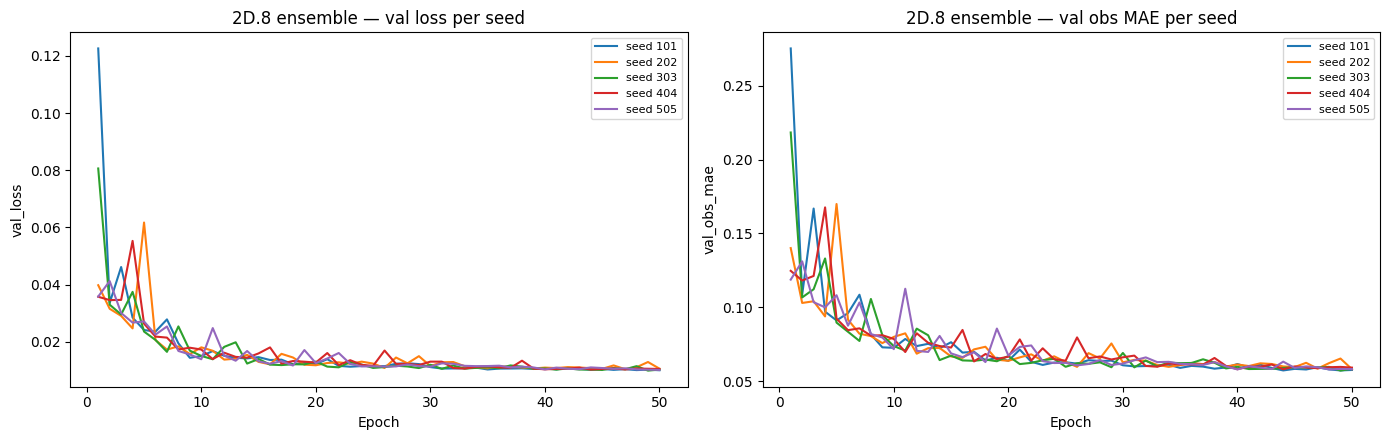

ensemble_val_mae: 0.057498008012771606
ensemble_test_mae: 0.07476689666509628
disagreement_test_stats: {'min': 0.0002421328390482813, 'mean': 0.009395559318363667, 'max': 0.31867948174476624, 'any_positive': True, 'any_negative': False}


In [13]:
ens = pd.read_csv(RUNS / '2D8' / 'training_curves.csv')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for seed, sub in ens.groupby('seed'):
    axes[0].plot(sub['epoch'], sub['val_loss'],  label=f'seed {seed}')
    axes[1].plot(sub['epoch'], sub['val_obs_mae'], label=f'seed {seed}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('val_loss')
axes[0].set_title('2D.8 ensemble — val loss per seed'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('val_obs_mae')
axes[1].set_title('2D.8 ensemble — val obs MAE per seed'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

m8 = json.loads((RUNS / '2D8' / 'manifest.json').read_text())
print('ensemble_val_mae:',  m8.get('ensemble_val_mae'))
print('ensemble_test_mae:', m8.get('ensemble_test_mae'))
print('disagreement_test_stats:', m8.get('disagreement_test_stats'))


## 6. Acceptance-criteria map (Phase 2 roadmap §6)

| # | Criterion                                            | Evidence (paths)                                                                                                                                                                                          | Status |
|---|---|---|---|
| 1 | Model-agnostic uncertainty evaluator + tests         | `src/neural_iv_surface_inference/evaluation/` + W1 tests; same evaluator drives all four rows of `results/2D/comparison_summary.csv`.                                                                      | PASS   |
| 2 | No-arbitrage diagnostics + tests                     | `src/neural_iv_surface_inference/diagnostics/`; per-row `*_violation` columns in `results/2D/.../predictions_decisions.csv`.                                                                              | PASS   |
| 3 | Masking-sensitivity harness                          | W2 harness wired into `scripts/run_decision_layer_eval.py` (`n_draws=5`, `keep_fraction=0.8`); per-row `uncertainty` carries the masking-stability component.                                              | PASS   |
| 4 | Conditional neural surface model on Phase 1 benchmarks | `artifacts/runs/2D7/<head_kind>/manifest.json` + `training_curve.csv` + `test_predictions.csv`.                                                                                                          | PASS   |
| 5 | Decision-grade outputs                               | `results/2D/.../conditional_calibrated/predictions_decisions.csv` columns: `iv_pred`, `confidence_score`, `lower`, `upper`, `abstain_flag`, `tradability_score`, `*_violation`, `decision_reason`.        | PASS   |
| 6 | Calibration is demonstrated                          | `results/2D/.../conditional_calibrated/metrics_summary.csv` (test coverage 0.9184); 2D.4 full fold 0.8955; hi-conf MAE 0.0606 < 0.0855. Calibrator: `artifacts/calibration/2d4_calibrator.json`.            | PASS   |
| 7 | Reproducibility + evidence discipline                | `artifacts/runs/2D7/`, `artifacts/runs/2D8/`, `results/2D/`, closing journal entry 2026-05-25T11:00.                                                                                                       | PASS   |


## 7. Open questions / known limitations

1. **Decision-layer `max_relative_width` retuning** — current threshold
   of 0.5 is tighter than the calibrated 90 % band (relative width ≈
   3.29), so `abstain_rate = 1.0` on the calibrated predictor. Next
   decision: widen to ~3.5 and re-score, or split abstention into
   "structural-flag" vs "width" reasons.
2. **Quantile + conformal under-coverage on chronological splits** —
   conformal calibration assumes exchangeability; the chronological
   val/test split breaks it (~4.3 pp gap). Gaussian + ensemble fusion
   is the shipped path. Next decision: keep the quantile head as
   diagnostic-only or remove from the calibration runner.
3. **2D.9 ran with `max_dates_per_split=10` on CPU** (pod GPU/torch
   kernel mismatch). Full-fold coverage is **0.8955** from the 2D.4
   verification. Next decision: re-run 2D.9 on the full test fold once
   torch is upgraded.
4. **Baseline predictors carry no calibrated band.** Interpolation, MLP,
   and the point conditional flow through the W5 decision layer via a
   degenerate full-confidence shim. Next decision: add a residual-
   bootstrap quantile band to baselines, or document the reliability
   layer as conditional-only.
5. **Forbidden-flag violations cluster at the test-fold tails.** 7,476
   structural-flag violations on the 64,610-row test slice (~11.6 %).
   Next decision: structural-flag severity feeding `tradability_score`,
   or hard structural penalty in training (Phase 3 framing).

## 8. Reproducing this notebook

```bash
python3 scripts/generate_phase2_results_notebook.py
jupyter nbconvert --to notebook --execute \
    notebooks/05_phase2_results.ipynb --output /tmp/_2D10_check.ipynb
```

No new training, no new scoring — every numeric claim above traces to a
committed artifact path.
